In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Load the data and recreate the top cell
print("Loading data for feature engineering...")
df_lte = pd.read_csv('./data/Dataset_02_LTE_1800.csv')
df_lte['Timestamp'] = pd.to_datetime(df_lte['Timestamp'])

numeric_cols = df_lte.select_dtypes(include=['float64', 'int64']).columns
df_lte[numeric_cols] = df_lte[numeric_cols].fillna(0)

df_lte['Cell_ID'] = df_lte['Base station'] + "_Sec_" + df_lte['Sector'].astype(str)

top_cell = df_lte.groupby('Cell_ID')['4G data volume DL'].sum().idxmax()
df_top_cell = df_lte[df_lte['Cell_ID'] == top_cell].set_index('Timestamp')

Loading data for feature engineering...


In [3]:
# 2. Resample to a strict 15-minute grid (Fixing the duplicates!)
print(f"Resampling data for {top_cell} to a strict 15-minute grid...")
df_target = df_top_cell.resample('15min').agg({
    '4G data volume DL': 'sum',
    '4G RB utilization': 'mean'
}).fillna(0)

Resampling data for Site 265_Sec_3 to a strict 15-minute grid...


In [4]:
# 3. Create Temporal Features
print("Engineering time and lag features...")
df_target['hour'] = df_target.index.hour
df_target['minute'] = df_target.index.minute
df_target['day_of_week'] = df_target.index.dayofweek
df_target['is_weekend'] = df_target['day_of_week'].isin([5, 6]).astype(int)

Engineering time and lag features...


In [5]:
# 4. Create Lag Features (Historical traffic inputs)
# 1 step = 15 minutes.
df_target['vol_lag_1'] = df_target['4G data volume DL'].shift(1)   # 15 mins ago
df_target['vol_lag_4'] = df_target['4G data volume DL'].shift(4)   # 1 hour ago
df_target['vol_lag_96'] = df_target['4G data volume DL'].shift(96) # 24 hours ago

In [6]:
# 5. Create Target Variable (What the model needs to predict)
# We shift the volume backwards by 1 so the current row contains the NEXT 15 min volume
df_target['target_15m_ahead'] = df_target['4G data volume DL'].shift(-1)

# 6. Drop rows with NaNs (caused by the 24-hour lag and target shift)
df_target = df_target.dropna()


Saved engineered dataset to: ./data/engineered_features.csv

Final Shape: (8206, 10)

--- Engineered Features (First 5 Rows) ---


,4G data volume DL,4G RB utilization,hour,minute,day_of_week,is_weekend,vol_lag_1,vol_lag_4,vol_lag_96,target_15m_ahead
Timestamp,,,,,,,,,,
2025-02-08 19:45:00,3681.42,37.080,19,45,5,1,3664.64,3858.84,3612.70,3940.28
2025-02-08 20:00:00,3940.28,36.940,20,0,5,1,3681.42,4076.92,0.00,3480.05
2025-02-08 20:15:00,3480.05,37.030,20,15,5,1,3940.28,4013.78,3170.45,3262.53
2025-02-08 20:30:00,3262.53,37.065,20,30,5,1,3480.05,3664.64,0.00,3597.45
2025-02-08 20:45:00,3597.45,36.915,20,45,5,1,3262.53,3681.42,3636.72,3865.33


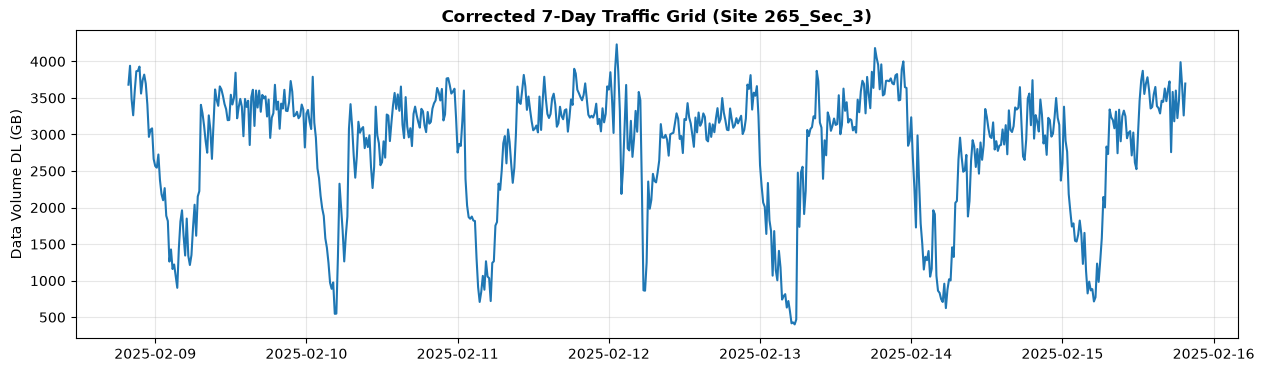

In [7]:
# 7. Save this cleaned dataset to use in the ML model
output_file = './data/engineered_features.csv'
df_target.to_csv(output_file)
print(f"\nSaved engineered dataset to: {output_file}")

print(f"\nFinal Shape: {df_target.shape}")
print("\n--- Engineered Features (First 5 Rows) ---")
display(df_target.head())

# 8. Plot the corrected 7-day grid
plt.figure(figsize=(15, 4))
plt.plot(df_target.index[:672], df_target['4G data volume DL'].iloc[:672], color='tab:blue')
plt.title(f"Corrected 7-Day Traffic Grid ({top_cell})", fontweight='bold')
plt.ylabel("Data Volume DL (GB)")
plt.grid(True, alpha=0.3)
plt.show()